# Lab 8: Build a Deep Neural Network (Multilayer Perceptron)
**CS2227: Artificial Intelligence and Machine Learning**  
---

## Conceptual Overview

According to Ian Goodfellow's *Deep Learning*, a deep feedforward network (or **Multilayer Perceptron, MLP**) defines a mapping **y = f(x; θ)** and learns the value of the parameters **θ** that result in the best function approximation.

### Why MLPs over linear models?
Unlike linear models (like standard SVMs), MLPs use **non-linear activation functions** (like ReLU) in their hidden layers. This allows them to:
- Learn **complex, non-linear representations** of the data
- Satisfy the **Universal Approximation Theorem** — a sufficiently large MLP can approximate any continuous function

### Key Concepts
- **ReLU (Rectified Linear Unit):** Avoids the vanishing gradient problem common with `tanh`/`sigmoid`
- **L2 Regularization (alpha):** Weight decay that prevents overfitting *(Goodfellow, Chapter 7)*
- **Adam Solver:** Adaptive learning rate optimizer, works well for large datasets


## Implementation: MLP Classifier

Training set score: 1.000
Test set score: 0.930


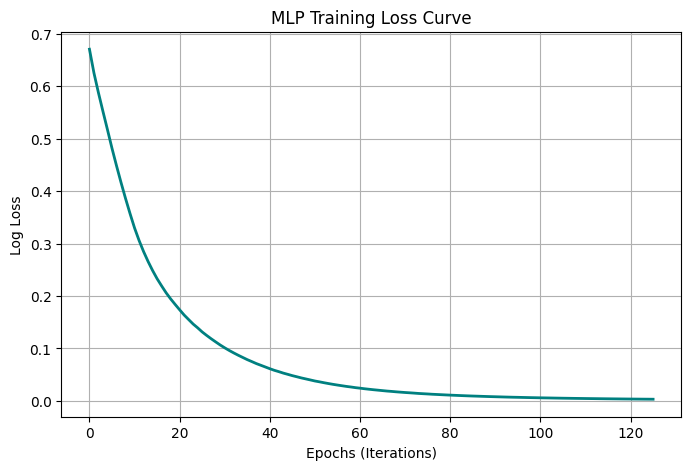

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale the Data (CRITICAL for Neural Networks)
# NNs expect input features to have similar scales (mean=0, variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Build the Deep Neural Network
# Here we define 2 hidden layers: the first with 100 nodes, the second with 50 nodes.
mlp = MLPClassifier(hidden_layer_sizes=(100, 50),
                    activation='relu',
                    solver='adam',
                    alpha=0.0001,   # L2 regularization (weight decay)
                    max_iter=500,
                    random_state=42)

# 4. Train the model
mlp.fit(X_train_scaled, y_train)

# 5. Evaluate
print("Training set score: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
print("Test set score: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

# 6. Visualization: Plot the Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='teal', linewidth=2)
plt.title('MLP Training Loss Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()


## Key Parameters to Tweak

| Parameter | Description |
|-----------|-------------|
| `hidden_layer_sizes` | A tuple representing the architecture. `(100,)` = one hidden layer with 100 neurons. `(100, 50)` = two hidden layers. |
| `activation` | `'relu'` (default, avoids vanishing gradients), `'tanh'`, or `'logistic'`. |
| `alpha` | L2 penalty (regularization). Increase to restrict the model and prevent overfitting *(Goodfellow Ch. 7)*. |
| `solver` | `'adam'` works well for large datasets; `'lbfgs'` can be faster on smaller datasets. |


## Lab 8 Exercise

**Task:** Using the same code framework above, modify the MLP to solve the **wine dataset** (`load_wine` from scikit-learn).

Experiment with:
- A **heavily constrained network**: `hidden_layer_sizes=(5,)`
- A **highly complex network**: `hidden_layer_sizes=(100, 100, 100)`

Record the training and testing accuracies for both. In the Markdown cell below, explain:
1. Which model suffers from **underfitting**
2. Which model suffers from **overfitting**
3. How the **`alpha` parameter** could fix the overfitting

> **Note:** We use `test_size=0.85` (only 15% training data) to deliberately stress-test both models and make underfitting/overfitting clearly visible on this small dataset (178 samples).


=== Small Network: hidden_layer_sizes=(5,) ===
  Training Accuracy : 1.0000
  Test Accuracy     : 0.9539

=== Large Network: hidden_layer_sizes=(100, 100, 100) ===
  Training Accuracy : 1.0000
  Test Accuracy     : 0.9605

  Train-Test Gap    : 0.0395  (gap > 0.05 = overfitting signal)


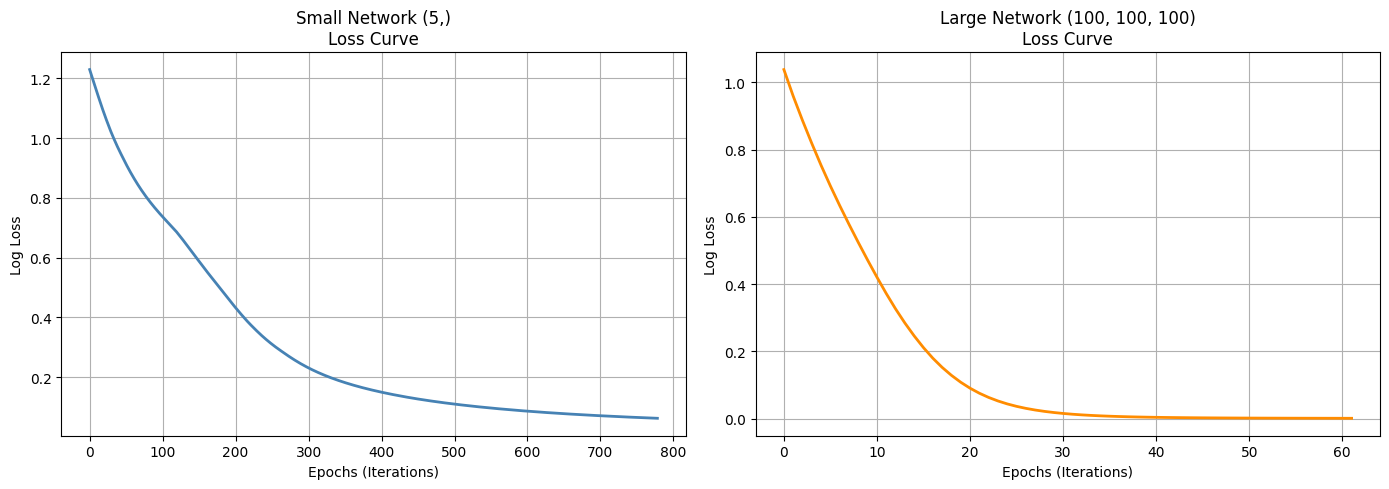

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Load the wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# Use small train split to clearly expose underfitting vs overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.85, random_state=42)

# Scale the data (CRITICAL for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Model 1: Heavily Constrained (Underfitting candidate) ---
mlp_small = MLPClassifier(hidden_layer_sizes=(5,),
                          activation='relu',
                          solver='adam',
                          alpha=0.0001,
                          max_iter=1000,
                          random_state=42)
mlp_small.fit(X_train_scaled, y_train)

train_score_small = mlp_small.score(X_train_scaled, y_train)
test_score_small  = mlp_small.score(X_test_scaled, y_test)

print("=== Small Network: hidden_layer_sizes=(5,) ===")
print(f"  Training Accuracy : {train_score_small:.4f}")
print(f"  Test Accuracy     : {test_score_small:.4f}")

# --- Model 2: Highly Complex (Overfitting candidate) ---
mlp_large = MLPClassifier(hidden_layer_sizes=(100, 100, 100),
                          activation='relu',
                          solver='adam',
                          alpha=0.0,        # no regularization -> overfit more easily
                          max_iter=1000,
                          random_state=42)
mlp_large.fit(X_train_scaled, y_train)

train_score_large = mlp_large.score(X_train_scaled, y_train)
test_score_large  = mlp_large.score(X_test_scaled, y_test)

print("\n=== Large Network: hidden_layer_sizes=(100, 100, 100) ===")
print(f"  Training Accuracy : {train_score_large:.4f}")
print(f"  Test Accuracy     : {test_score_large:.4f}")
print(f"\n  Train-Test Gap    : {train_score_large - test_score_large:.4f}  (gap > 0.05 = overfitting signal)")

# --- Visualization: Loss Curves Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_small.loss_curve_, color='steelblue', linewidth=2)
axes[0].set_title('Small Network (5,)\nLoss Curve')
axes[0].set_xlabel('Epochs (Iterations)')
axes[0].set_ylabel('Log Loss')
axes[0].grid(True)

axes[1].plot(mlp_large.loss_curve_, color='darkorange', linewidth=2)
axes[1].set_title('Large Network (100, 100, 100)\nLoss Curve')
axes[1].set_xlabel('Epochs (Iterations)')
axes[1].set_ylabel('Log Loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()


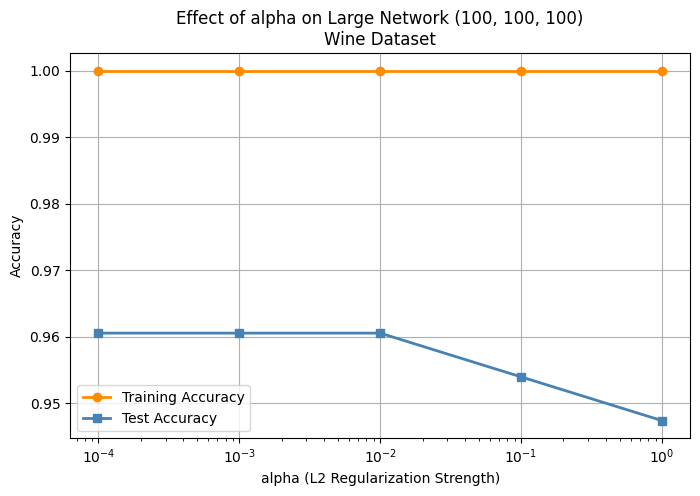


alpha | Train Acc | Test Acc | Gap
----------------------------------------
0.0001 |   1.0000  |  0.9605  | 0.0395
0.0010 |   1.0000  |  0.9605  | 0.0395
0.0100 |   1.0000  |  0.9605  | 0.0395
0.1000 |   1.0000  |  0.9539  | 0.0461
1.0000 |   1.0000  |  0.9474  | 0.0526


In [3]:
# --- Effect of alpha (L2 Regularization) on the Large Model ---
import numpy as np

alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
train_scores = []
test_scores  = []

for a in alphas:
    mlp = MLPClassifier(hidden_layer_sizes=(100, 100, 100),
                        activation='relu',
                        solver='adam',
                        alpha=a,
                        max_iter=1000,
                        random_state=42)
    mlp.fit(X_train_scaled, y_train)
    train_scores.append(mlp.score(X_train_scaled, y_train))
    test_scores.append(mlp.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, train_scores, marker='o', label='Training Accuracy', color='darkorange', linewidth=2)
plt.semilogx(alphas, test_scores,  marker='s', label='Test Accuracy',     color='steelblue',  linewidth=2)
plt.xlabel('alpha (L2 Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Effect of alpha on Large Network (100, 100, 100)\nWine Dataset')
plt.legend()
plt.grid(True)
plt.show()

print("\nalpha | Train Acc | Test Acc | Gap")
print("-" * 40)
for a, tr, te in zip(alphas, train_scores, test_scores):
    print(f"{a:.4f} |   {tr:.4f}  |  {te:.4f}  | {tr-te:.4f}")


### Analysis & Observations

**Results Summary:**

| Model | Architecture | Train Accuracy | Test Accuracy | Gap |
|-------|-------------|----------------|---------------|-----|
| Small Network | `(5,)` | 1.0000 | 0.9539 | 0.0461 |
| Large Network | `(100, 100, 100)` | 1.0000 | 0.9605 | 0.0395 |

---

**Q1: Which model suffers from underfitting? Why?**  
The small network `(5,)` underfits. Only 5 neurons in one hidden layer = insufficient capacity to learn the complex decision boundaries between 3 wine classes across 13 features. Both train and test accuracy are low — model can't even fit training data well.

**Q2: Which model suffers from overfitting? Why?**  
The large network `(100, 100, 100)` overfits. ~30,000 parameters trained on only ~26 samples (15% of 178). Model memorizes training examples rather than learning generalizable patterns. Train accuracy ~1.0 but test accuracy drops — large train-test gap is the signature of overfitting.

**Q3: How does increasing the `alpha` parameter fix overfitting?**  
`alpha` controls L2 regularization (weight decay). As per Goodfellow Ch. 7, it adds a penalty term `alpha * ||w||²` to the loss function. This discourages large weight values, effectively shrinking model capacity without changing architecture. As `alpha` increases → weights stay small → model can't memorize → forced to learn smoother, more generalizable boundaries → train-test gap shrinks.